In [4]:
import pandas as pd

In [5]:
dataset=pd.read_csv("50_Startups.csv")

In [6]:
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='object')

In [7]:
dataset=pd.get_dummies(dataset,drop_first=True)

In [8]:
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit',
       'State_Florida', 'State_New York'],
      dtype='object')

In [9]:
independent=dataset[['R&D Spend', 'Administration', 'Marketing Spend', 'State_Florida', 'State_New York']]

In [10]:
dependent=dataset[['Profit']]

In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(independent,dependent,test_size=0.3,random_state=0)

In [98]:
from sklearn.tree import DecisionTreeRegressor
regressor= DecisionTreeRegressor( criterion='poisson', splitter='best', max_features = 1)
regressor=regressor.fit(X_train,Y_train)

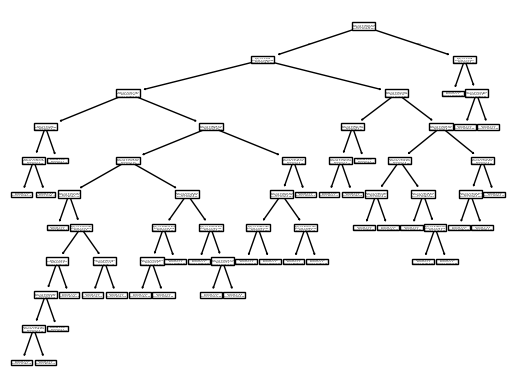

In [16]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [99]:
y_pred=regressor.predict(X_test)
y_pred

array([108733.99, 149759.96, 141585.52,  90708.19, 155752.6 , 125370.37,
        69758.98, 101004.64, 108733.99, 155752.6 ,  99937.59, 125370.37,
       108733.99,  78239.91, 141585.52])

In [100]:
from sklearn.metrics import r2_score
r_score=r2_score(Y_test,y_pred)
r_score

0.7473480398720631